In [ ]:
prefix1  <- "healthy"
prefix2  <- "crypto"
label1   <- "healthy"
label2   <- "crypto"
base_dir <- "/LAB-DATA/GLiCID/users/e244507t@univ-nantes.fr/Cellchat"

## Chargement des packages

In [2]:
suppressPackageStartupMessages({
  library(CellChat)
  library(patchwork)
})
options(stringsAsFactors = FALSE)

Warning message:
“le package ‘CellChat’ a été compilé avec la version R 4.5.3”


## Chemins

In [3]:
rds1    <- file.path(base_dir, "results", "Procedure_1", prefix1,
                     paste0("cellchat_", prefix1, ".rds"))
rds2    <- file.path(base_dir, "results", "Procedure_1", prefix2,
                     paste0("cellchat_", prefix2, ".rds"))
out_dir <- file.path(base_dir, "results", "Procedure_2",
                     paste0(prefix1, "_vs_", prefix2))
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

cat("RDS 1 :", rds1, "\n")
cat("RDS 2 :", rds2, "\n")
cat("Output:", out_dir, "\n")

RDS 1 : /LAB-DATA/GLiCID/users/e244507t@univ-nantes.fr/Cellchat/results/Procedure_1/healthy/cellchat_healthy.rds 
RDS 2 : /LAB-DATA/GLiCID/users/e244507t@univ-nantes.fr/Cellchat/results/Procedure_1/bi-crypto/cellchat_bi-crypto.rds 
Output: /LAB-DATA/GLiCID/users/e244507t@univ-nantes.fr/Cellchat/results/Procedure_2/healthy_vs_bi-crypto 


## Step 1 — Chargement des objets CellChat

In [4]:
if (!file.exists(rds1)) stop(paste0("Fichier introuvable : ", rds1))
if (!file.exists(rds2)) stop(paste0("Fichier introuvable : ", rds2))

cellchat.A <- readRDS(rds1)
cat(paste0("[", label1, "] — ", length(levels(cellchat.A@idents)),
           " groupes : ", paste(levels(cellchat.A@idents), collapse = ", "), "\n"))

cellchat.B <- readRDS(rds2)
cat(paste0("[", label2, "] — ", length(levels(cellchat.B@idents)),
           " groupes : ", paste(levels(cellchat.B@idents), collapse = ", "), "\n"))

[healthy] — 8 groupes : SSC, Spermatocyte, Spermatid, Sertoli, Leydig, Myoid, Fibroblast, Endothelial
[bi-crypto] — 8 groupes : SSC, Spermatocyte, Spermatid, Sertoli, Leydig, Myoid, Fibroblast, Endothelial


## Step 2 — Fusion des objets CellChat

In [5]:
object.list <- list()
object.list[[label1]] <- cellchat.A
object.list[[label2]] <- cellchat.B

cat("Fusion de :", label1, "+", label2, "\n")
cellchat <- mergeCellChat(object.list, add.names = names(object.list))

cat("Groupes dans l'objet mergé :", length(levels(cellchat@idents)), "\n")
cat("Datasets :", paste(unique(cellchat@meta$datasets), collapse = ", "), "\n")

Fusion de : healthy + bi-crypto 


Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



Groupes dans l'objet mergé : 0 
Datasets : healthy, bi-crypto 


## Sauvegarde

In [6]:
rdata_list   <- file.path(out_dir, paste0("cellchat_object.list_", prefix1, "_", prefix2, ".RData"))
rdata_merged <- file.path(out_dir, paste0("cellchat_merged_",      prefix1, "_", prefix2, ".RData"))

save(object.list, file = rdata_list)
save(cellchat,    file = rdata_merged)

cat("Sauvegardé :", rdata_list,   "\n")
cat("Sauvegardé :", rdata_merged, "\n")
cat("\n--- Procedure 2 Steps 1-3 complete ---\n")

Sauvegardé : /LAB-DATA/GLiCID/users/e244507t@univ-nantes.fr/Cellchat/results/Procedure_2/healthy_vs_bi-crypto/cellchat_object.list_healthy_bi-crypto.RData 
Sauvegardé : /LAB-DATA/GLiCID/users/e244507t@univ-nantes.fr/Cellchat/results/Procedure_2/healthy_vs_bi-crypto/cellchat_merged_healthy_bi-crypto.RData 

--- Procedure 2 Steps 1-3 complete ---


---

# CellChat Procedure 2 — Step 5: Compare interactions

## Chargement de l'objet mergé

In [7]:
out_dir_step5 <- file.path(base_dir, "results", "Procedure_2",
                           paste0(prefix1, "_vs_", prefix2), "comparison", "step5")
dir.create(out_dir_step5, showWarnings = FALSE, recursive = TRUE)

rdata_merged <- file.path(base_dir, "results", "Procedure_2",
                          paste0(prefix1, "_vs_", prefix2),
                          paste0("cellchat_merged_", prefix1, "_", prefix2, ".RData"))

if (!file.exists(rdata_merged)) stop(paste0("Fichier introuvable : ", rdata_merged))
load(rdata_merged)  # charge 'cellchat'
cat("Datasets :", paste(unique(cellchat@meta$datasets), collapse = ", "), "\n")

Datasets : healthy, bi-crypto 


## Comparing number of interactions and interaction strenght

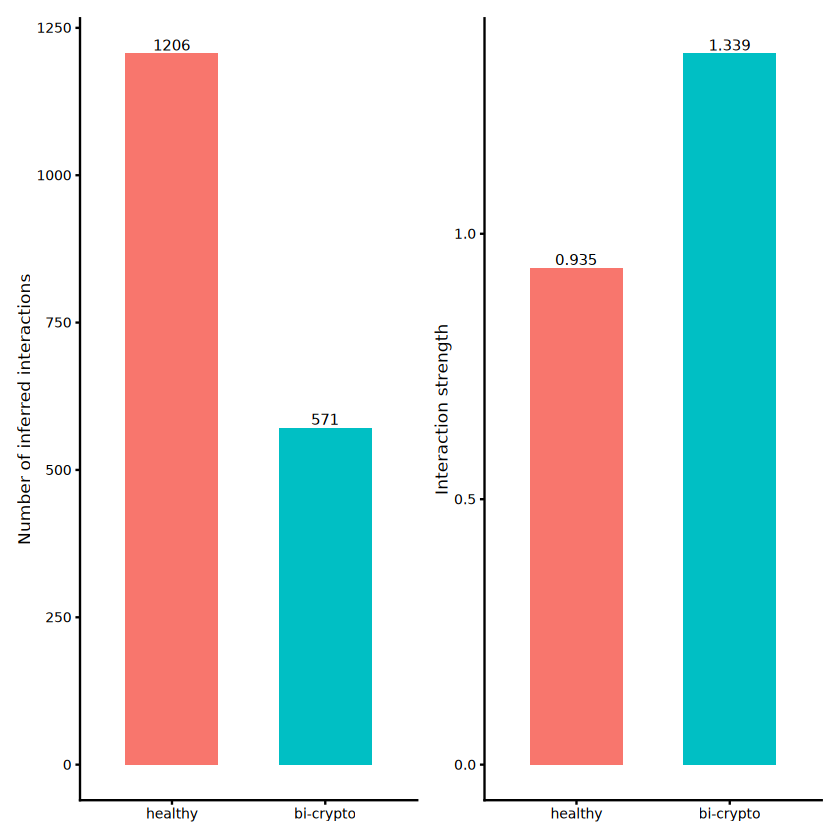

In [8]:
gg1 <- compareInteractions(cellchat, show.legend = FALSE, group = c(1, 2))
gg2 <- compareInteractions(cellchat, show.legend = FALSE, group = c(1, 2), measure = "weight")
gg1 + gg2

## Circle plots (differential)

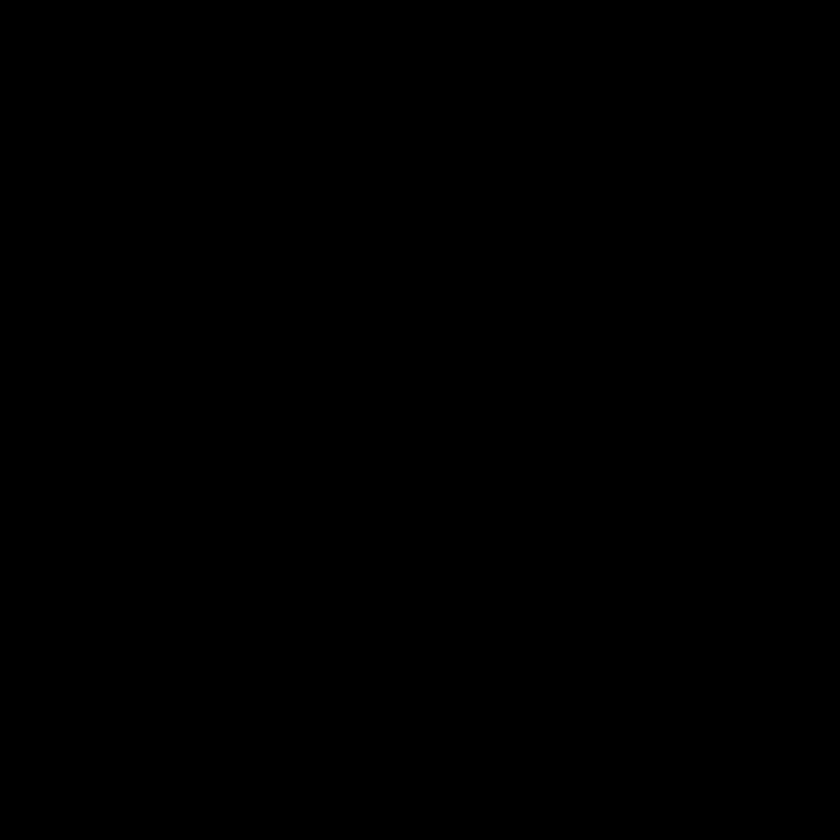

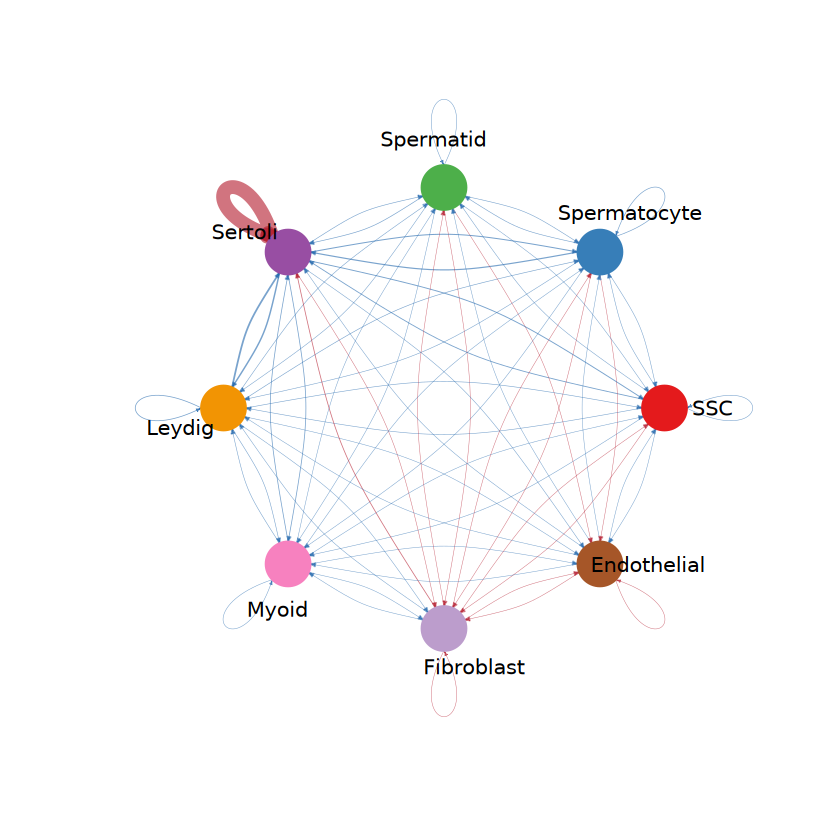

png 
  3

Saved: /LAB-DATA/GLiCID/users/e244507t@univ-nantes.fr/Cellchat/results/Procedure_2/healthy_vs_bi-crypto/comparison/step6/diff_circle_both.png 


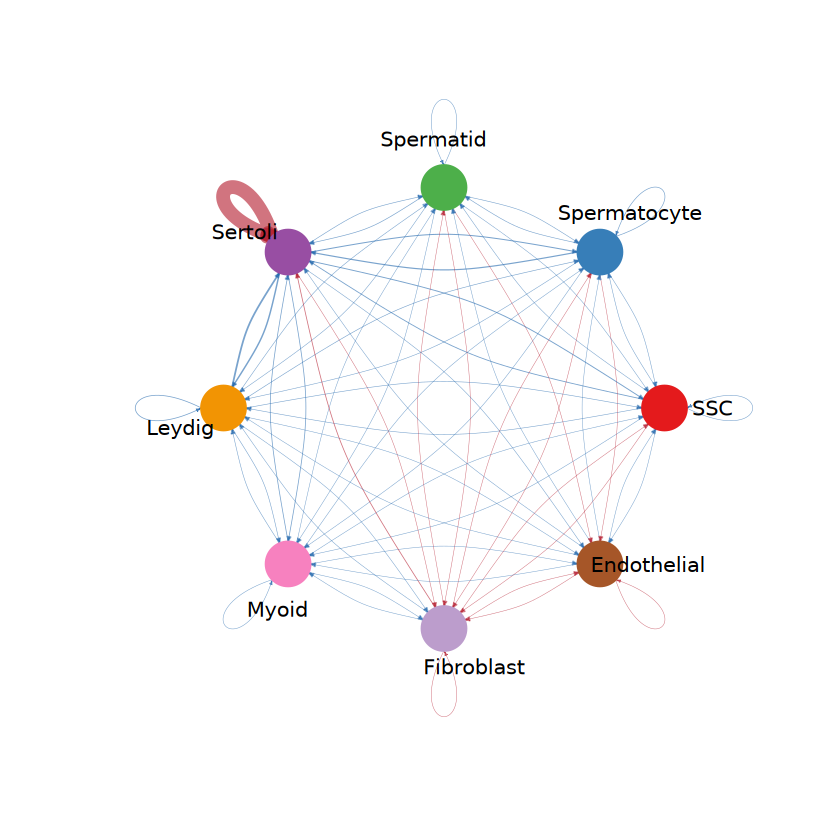

In [19]:
out_dir_step6 <- file.path(base_dir, "results", "Procedure_2",
                           paste0(prefix1, "_vs_", prefix2), "comparison", "step6")
dir.create(out_dir_step6, showWarnings = FALSE, recursive = TRUE)

png(file.path(out_dir_step6, "diff_circle_both.png"), width = 1200, height = 600, res = 120)
par(mfrow = c(1,2), xpd=TRUE)

netVisual_diffInteraction(cellchat, weight.scale = T, measure = "count")
netVisual_diffInteraction(cellchat, weight.scale = T, measure = "weight")
dev.off()
cat("Saved:", file.path(out_dir_step6, "diff_circle_both.png"), "\n")

##  Heatmaps (differential)

Do heatmap based on a merged object 




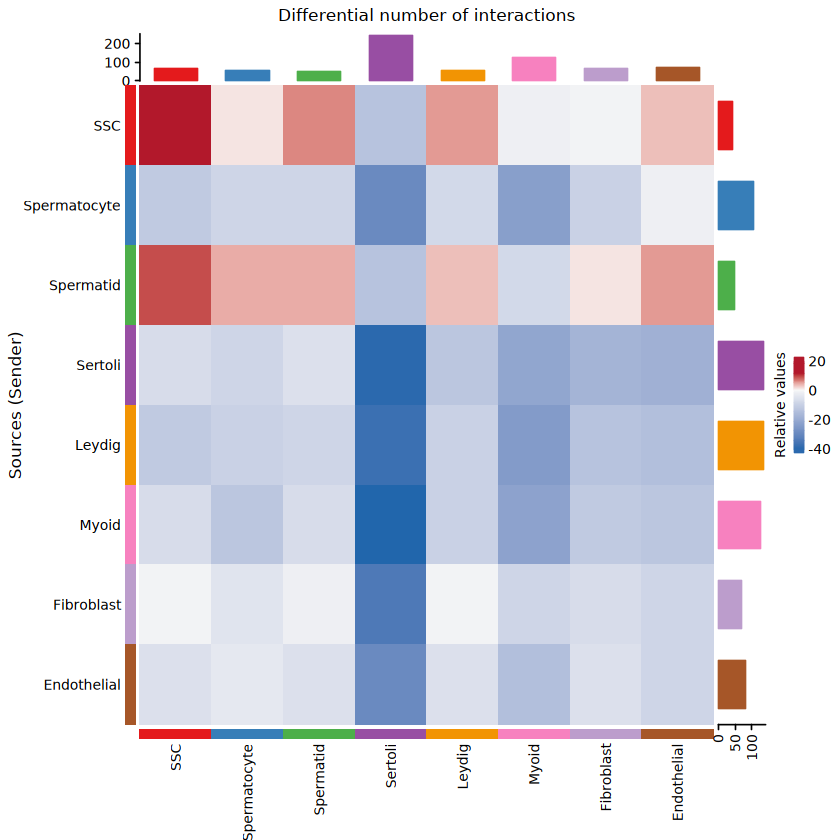

In [10]:
gg1 <- netVisual_heatmap(cellchat)
ComplexHeatmap::draw(gg1)

Do heatmap based on a merged object 




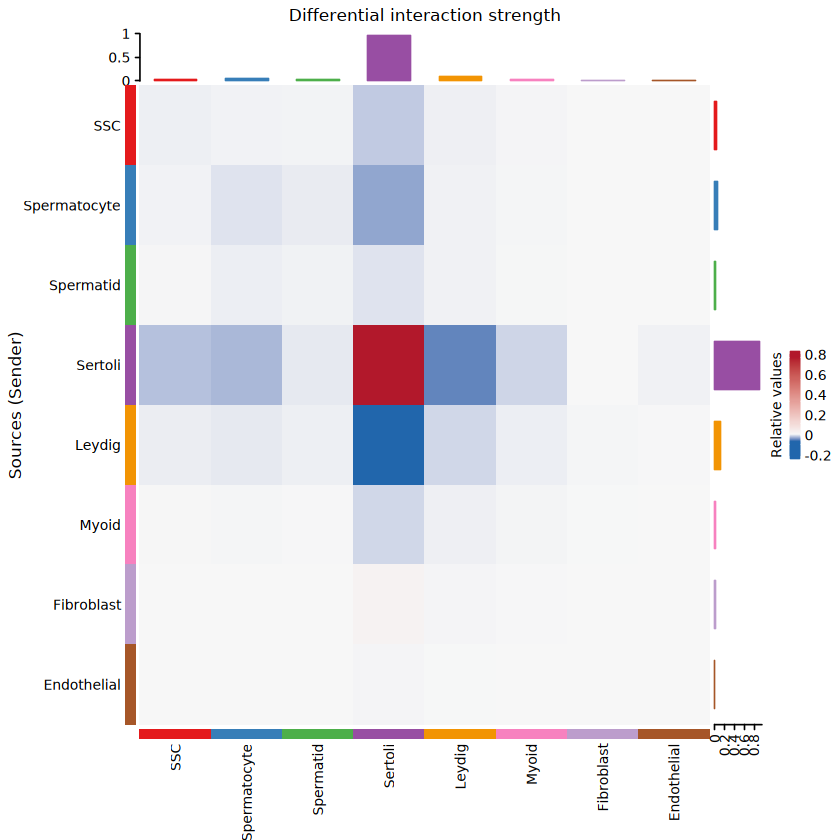

In [11]:
gg2 <- netVisual_heatmap(cellchat, measure = "weight")
ComplexHeatmap::draw(gg2)